# Medical Cost Prediction — Data Preprocessing & Preparation

## Problem statement
An insurance company wants to predict individual medical insurance costs based on demographic and lifestyle information.

## Dataset
Medical Cost Personal Dataset: `insurance.csv`

## Learning goals
- Understand a tabular regression dataset
- Identify and clean data quality issues
- Encode categorical variables
- Scale numerical variables where appropriate
- Prepare train/test dataset splits for regression
- Bonus: compare model performance before and after preprocessing

## 1. Setup
Import the libraries needed for data inspection, preprocessing, visualization, and optional modeling.

In [120]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt

# Feature preprocessing and target transformation
from sklearn.compose import (
    ColumnTransformer,
    TransformedTargetRegressor
)
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

# Train / test split
from sklearn.model_selection import train_test_split

# Machine Learning pipelines
from sklearn.pipeline import Pipeline

# Regression models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Model evaluation metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

## 2. Load and Inspect the Data
Load the dataset and inspect its basic structure.

In [5]:
df = pd.read_excel("insurance.xlsx")

In [8]:
df.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [10]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


## 3. Data Understanding
Identify the target variable, numerical features, and categorical features.

Questions to answer:
- What does each column represent?
- Which column is the target?
- Which variables are numerical?
- Which variables are categorical?

| Column   | Meaning                                               | Type        |
| -------- | ----------------------------------------------------- | ----------- |
| age      | Age of the insured person                             | Numerical   |
| sex      | Gender (`male`, `female`)                             | Categorical |
| bmi      | Body Mass Index                                       | Numerical   |
| children | Number of dependent children covered by the insurance | Numerical   |
| smoker   | Whether the person smokes (`yes`, `no`)               | Categorical |
| region   | Region of residence in the US                         | Categorical |
| charges  | Annual medical insurance cost charged by the insurer  | **Target**  |


## 4. Data Quality Assessment
Check for missing values, duplicates, and inconsistent values.

In [13]:
# missing values
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [14]:
(df.astype(str)
   .apply(lambda col: col.str.strip())
   .eq("?")
   .sum())

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [17]:
# duplicate values
duplicate_count = df.duplicated().sum()
duplicates = df[df.duplicated(keep=False)]

print(f"duplicates: {duplicate_count}")

duplicates.sort_values(by=list(df.columns))

duplicates: 1


,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631


In [20]:
# Check categorical value consistency
categorical_features = ["sex", "smoker", "region"]

for col in categorical_features:
    print(f"\n")
    print(df[col].value_counts())



sex
male      676
female    662
Name: count, dtype: int64


smoker
no     1064
yes     274
Name: count, dtype: int64


region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


### Cleaning decisions
Document your cleaning decisions here:
- Are there missing values?
- Are there duplicate rows?
- Should duplicates be removed?
- Are categorical values consistent?

No missing values were found in the dataset.  
One exact duplicate row was identified and will be removed.  
All categorical variables contain consistent and valid values, so no additional cleaning was required.

## 5. Exploratory Data Analysis
Explore distributions and relationships with the target variable.

### functions

In [21]:
def plot_histogram(df, column, bins=30):
    df[column].hist(bins=bins)
    plt.title(column)
    plt.xlabel(column)
    plt.ylabel("Count")
    plt.show()

In [55]:
def print_skewness(df, column):
    print(f"skewness: {column}: {df[column].skew():.2f}")

In [30]:
def mean_target_by_numeric_bins(
    df,
    feature,
    target="charges",
    bins=5
):
    return (
        df.groupby(
            pd.cut(df[feature], bins=bins)
        )[target]
        .mean()
    )

In [34]:
def mean_target_by_category(
    df,
    category_column,
    target_column="charges"
):
    return (
        df.groupby(category_column)[target_column]
          .mean()
          .sort_values(ascending=False)
    )

In [31]:
def plot_mean_target_by_category(
    df,
    category_column,
    target_column="charges"
):
    (
        df.groupby(category_column)[target_column]
          .mean()
          .sort_values(ascending=False)
          .plot(kind="bar")
    )

    plt.title(
        f"Average {target_column} by {category_column}"
    )
    plt.ylabel(target_column)
    plt.show()

In [49]:
def analyse_categorical_feature(
    df,
    category_column,
    target_column="charges"
):
    print("Value counts:")
    print(df[category_column].value_counts())

    print("\nTarget by category:")
    print(mean_target_by_category(
        df,
        category_column,
        target_column
    ))

    plot_mean_target_by_category(
        df,
        category_column,
        target_column
    )

    print("\nTarget by category describe:")
    print(
        df.groupby(category_column)[target_column]
          .describe()
    )

In [57]:
def analyse_numeric_feature(
    df,
    feature_column,
    target_column="charges",
    bins=5
):
    print(f"Feature: {feature_column}")

    print("\nFeature describe:")
    print(df[feature_column].describe())

    print("\nFeature skewness:")
    print(f"{df[feature_column].skew():.2f}")

    print("\nCorrelation with target:")
    print(f"{df[feature_column].corr(df[target_column]):.2f}")

    print("\nAverage target by numeric bins:")
    print(
        mean_target_by_numeric_bins(
            df,
            feature_column,
            target=target_column,
            bins=bins
        )
    )

    print("\nFeature distribution:")
    plot_histogram(df, feature_column)

    print("\nFeature vs target:")
    df.plot(
        kind="scatter",
        x=feature_column,
        y=target_column,
        alpha=0.5
    )

    plt.title(f"{target_column} vs {feature_column}")
    plt.xlabel(feature_column)
    plt.ylabel(target_column)
    plt.show()

### analyse

#### target

skewness: charges: 1.52


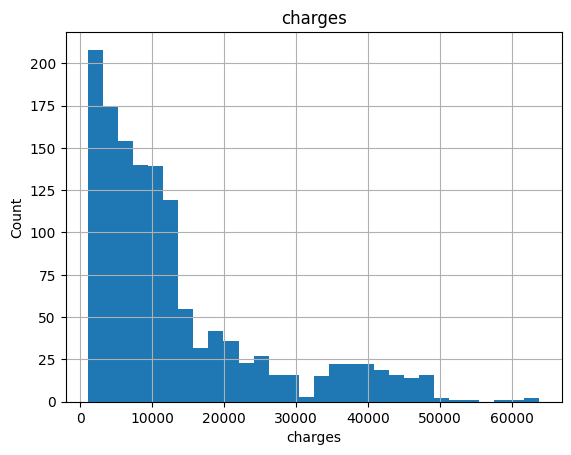

In [27]:
print_skewness(df, "charges")
plot_histogram(df, "charges")

The distribution of charges is strongly right-skewed (skewness = 1.52). Most policyholders have relatively low medical costs, while a small number have very high costs. This is a typical pattern for insurance expenditure data.

#### categorical features

Value counts:
smoker
no     1064
yes     274
Name: count, dtype: int64

Target by category:
smoker
yes    32050.231832
no      8434.268298
Name: charges, dtype: float64


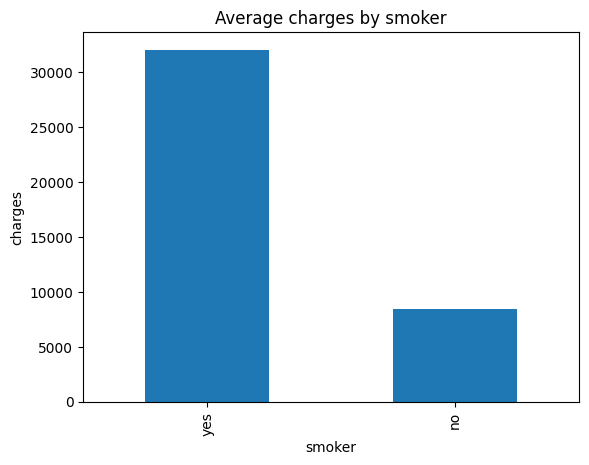


Target by category describe:
         count          mean           std         min           25%  \
smoker                                                                 
no      1064.0   8434.268298   5993.781819   1121.8739   3986.438700   
yes      274.0  32050.231832  11541.547176  12829.4551  20826.244213   

                50%           75%          max  
smoker                                          
no       7345.40530  11362.887050  36910.60803  
yes     34456.34845  41019.207275  63770.42801  


In [50]:
#smoker
analyse_categorical_feature(df, "smoker")

Smoking status shows the strongest relationship with medical costs among the categorical variables. Smokers account for only 20.5% of the dataset (274 individuals), yet their average charges ($32,050) are nearly four times higher than those of non-smokers ($8,434). The median charges for smokers ($34,456) are also substantially higher than for non-smokers ($7,345), indicating that the difference is not caused by a few extreme observations but is present across the smoker population.

Value counts:
sex
male      676
female    662
Name: count, dtype: int64

Target by category:
sex
male      13956.751178
female    12569.578844
Name: charges, dtype: float64


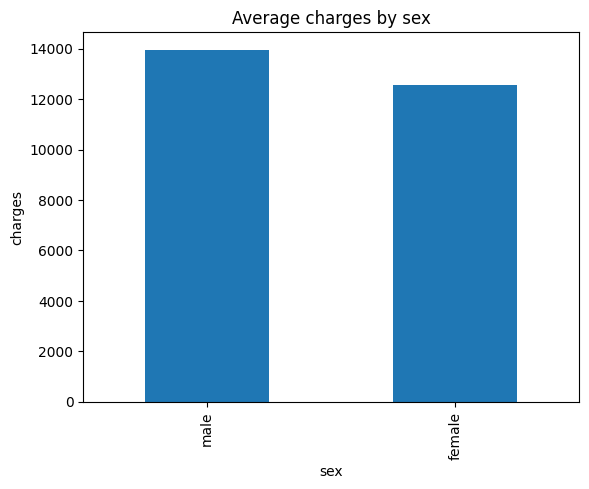


Target by category describe:
        count          mean           std        min        25%         50%  \
sex                                                                           
female  662.0  12569.578844  11128.703801  1607.5101  4885.1587  9412.96250   
male    676.0  13956.751178  12971.025915  1121.8739  4619.1340  9369.61575   

                 75%          max  
sex                                
female  14454.691825  63770.42801  
male    18989.590250  62592.87309  


In [51]:
#sex
analyse_categorical_feature(df, "sex")

The dataset is well balanced by sex. Males show slightly higher average charges than females, but the median charges are nearly identical. Therefore, sex appears to have only a limited influence on medical costs and is a much weaker predictor than smoking status.

Value counts:
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

Target by category:
region
southeast    14735.411438
northeast    13406.384516
northwest    12417.575374
southwest    12346.937377
Name: charges, dtype: float64


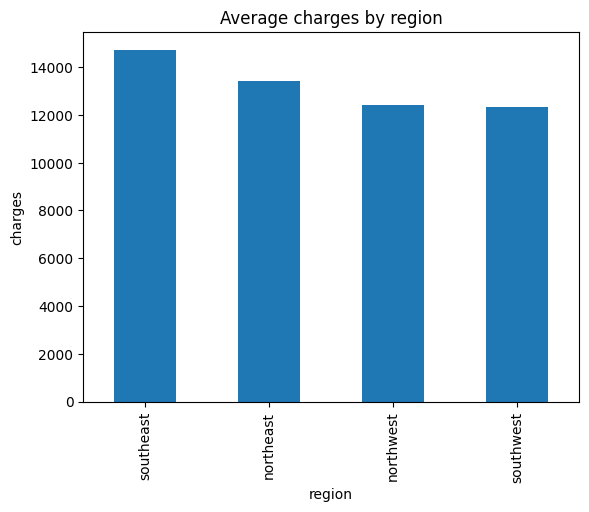


Target by category describe:
           count          mean           std        min          25%  \
region                                                                 
northeast  324.0  13406.384516  11255.803066  1694.7964  5194.322288   
northwest  325.0  12417.575374  11072.276928  1621.3402  4719.736550   
southeast  364.0  14735.411438  13971.098589  1121.8739  4440.886200   
southwest  325.0  12346.937377  11557.179101  1241.5650  4751.070000   

                    50%         75%          max  
region                                            
northeast  10057.652025  16687.3641  58571.07448  
northwest   8965.795750  14711.7438  60021.39897  
southeast   9294.131950  19526.2869  63770.42801  
southwest   8798.593000  13462.5200  52590.82939  


In [54]:
# regoin
analyse_categorical_feature(df, "region")

The dataset is well balanced across the four regions, with each region containing approximately 25% of the observations. Individuals living in the Southeast have the highest average medical charges ($14,735), while those living in the Southwest have the lowest ($12,347). However, the median charges are relatively similar across all regions, ranging from approximately $8,799 to $10,058. This suggests that region has some influence on medical costs, but the effect is considerably smaller than that of smoking status. The higher average charges observed in the Southeast may be partially driven by a larger number of high-cost observations.

#### numerical features

Feature: age

Feature describe:
count    1338.000000
mean       39.207025
std        14.049960
min        18.000000
25%        27.000000
50%        39.000000
75%        51.000000
max        64.000000
Name: age, dtype: float64

Feature skewness:
0.06

Correlation with target:
0.30

Average target by numeric bins:
age
(17.954, 27.2]     9098.192248
(27.2, 36.4]      10991.125921
(36.4, 45.6]      13628.318836
(45.6, 54.8]      15968.998082
(54.8, 64.0]      18513.276227
Name: charges, dtype: float64

Feature distribution:


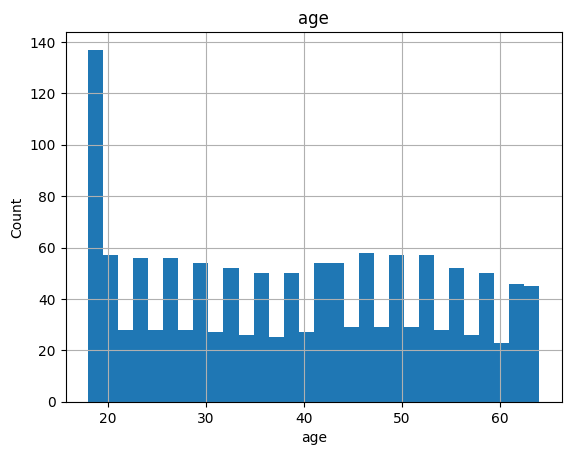


Feature vs target:


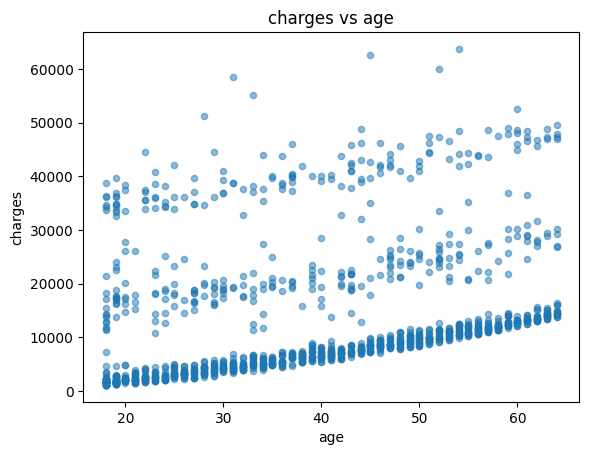

In [58]:
# age
analyse_numeric_feature(df, "age")

Age is approximately normally distributed (skewness = 0.06) and shows a moderate positive correlation with medical costs (correlation = 0.30). The average medical charges increase consistently across age groups, from approximately $9,098 for individuals aged 18–27 to $18,513 for individuals aged 55–64. This suggests that age is an important predictor of medical insurance costs.

Feature: bmi

Feature describe:
count    1338.000000
mean       30.663397
std         6.098187
min        15.960000
25%        26.296250
50%        30.400000
75%        34.693750
max        53.130000
Name: bmi, dtype: float64

Feature skewness:
0.28

Correlation with target:
0.20

Average target by numeric bins:
bmi
(15.923, 23.394]     9503.486692
(23.394, 30.828]    11554.830480
(30.828, 38.262]    15790.802305
(38.262, 45.696]    15258.426910
(45.696, 53.13]     17289.421583
Name: charges, dtype: float64

Feature distribution:


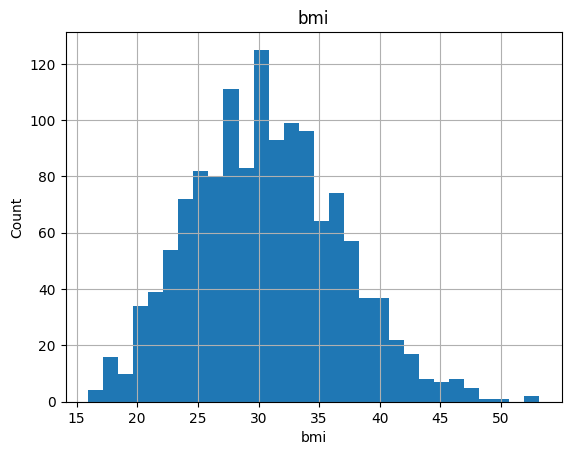


Feature vs target:


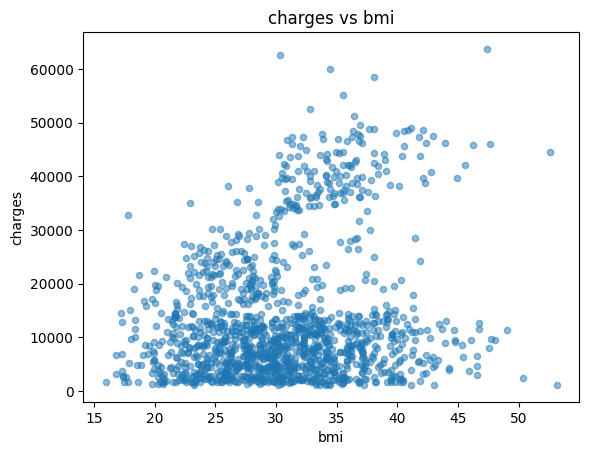

In [60]:
# bmi
analyse_numeric_feature(df, "bmi")

BMI is slightly right-skewed (skewness = 0.28) and shows a weak-to-moderate positive correlation with medical costs (correlation = 0.20). Average charges generally increase as BMI increases, rising from approximately $9,503 in the lowest BMI group to $17,289 in the highest BMI group. This suggests that individuals with higher BMI tend to incur higher medical costs, although the relationship is weaker than that observed for age and smoking status.

Feature: children

Feature describe:
count    1338.000000
mean        1.094918
std         1.205493
min         0.000000
25%         0.000000
50%         1.000000
75%         2.000000
max         5.000000
Name: children, dtype: float64

Feature skewness:
0.94

Correlation with target:
0.07

Average target by numeric bins:
children
(-0.005, 1.0]    12497.739052
(1.0, 2.0]       15073.563734
(2.0, 3.0]       15355.318367
(3.0, 4.0]       13850.656311
(4.0, 5.0]        8786.035247
Name: charges, dtype: float64

Feature distribution:


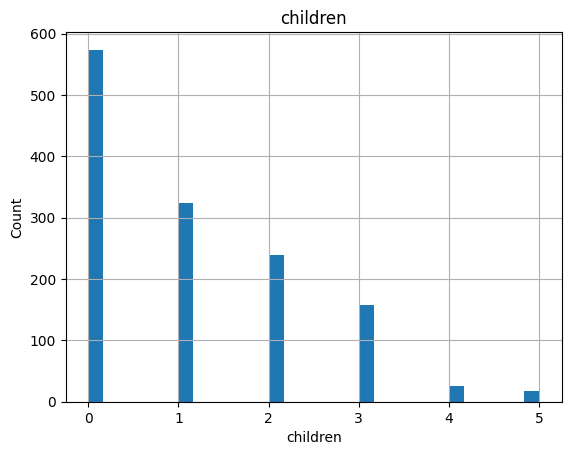


Feature vs target:


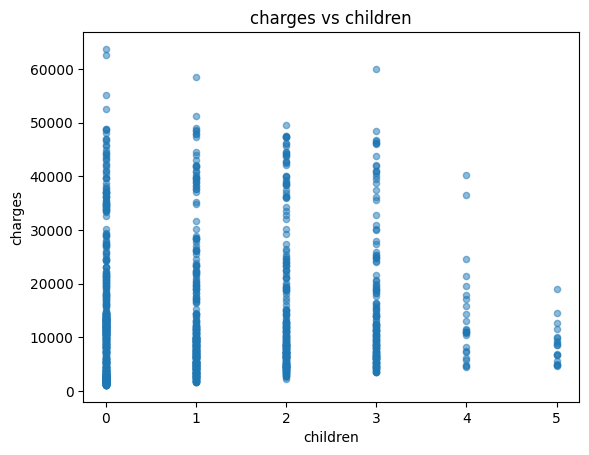

In [62]:
# children
analyse_numeric_feature(df, "children")

In [63]:
df["children"].value_counts().sort_index()

children
0    574
1    324
2    240
3    157
4     25
5     18
Name: count, dtype: int64

The relationship between the number of children and medical costs appears weak. Although average charges vary across groups, the groups with 4 and 5 children contain only 25 and 18 observations respectively, making their averages less reliable. Overall, the number of children shows only a weak correlation with medical costs (0.07).

| Feature | Type | Distribution / Balance | Correlation with Charges | Observed Relationship | Importance |
|----------|----------|----------|----------|----------|----------|
| **smoker** | Categorical | 1064 no (79.5%), 274 yes (20.5%) | N/A | Smokers have nearly 4 times higher average charges ($32,050 vs $8,434). Median charges are also much higher, indicating a strong effect across the population. | **Very Strong** |
| **age** | Numerical | Approximately symmetric (skewness = 0.06) | 0.30 | Charges increase consistently with age, from approximately $9,098 to $18,513 across age groups. | **Strong** |
| **bmi** | Numerical | Slightly right-skewed (skewness = 0.28) | 0.20 | Higher BMI is generally associated with higher charges, although the relationship is not perfectly linear. | **Moderate** |
| **region** | Categorical | Well balanced (~25% per region) | N/A | Southeast has the highest average charges, but regional differences are much smaller than smoking effects. | **Weak to Moderate** |
| **sex** | Categorical | Nearly balanced (676 male, 662 female) | N/A | Males have slightly higher average charges, but median charges are almost identical. | **Weak** |
| **children** | Numerical | Right-skewed (skewness = 0.94) | 0.07 | No clear trend. Groups with 4–5 children contain very few observations, making averages less reliable. | **Weak** |

### Key Findings

1. Smoking status shows the strongest relationship with medical costs.
2. Age is a strong predictor, with charges increasing consistently across age groups.
3. BMI has a moderate positive relationship with medical costs.
4. Region and sex show relatively small differences in average charges.
5. The number of children appears to have limited predictive power.
6. The target variable `charges` is strongly right-skewed (skewness = 1.52), suggesting that a log transformation may be considered during preprocessing.

## 6. Outlier Inspection
Inspect potential outliers in `charges`, `bmi`, and other numerical columns.

Questions to answer:
- Are extreme values likely to be errors or valid observations?
- Should they be kept, capped, transformed, or removed?

### functions

In [65]:
def plot_boxplot(df, column):
    df.boxplot(column=column)
    plt.title(column)
    plt.show()

In [67]:
def count_outliers_iqr(df, column):
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = df[
        (df[column] < lower) |
        (df[column] > upper)
    ]

    print(f"{column}")
    print(f"Lower bound: {lower:.2f}")
    print(f"Upper bound: {upper:.2f}")
    print(f"Outliers: {len(outliers)}")

### analyse

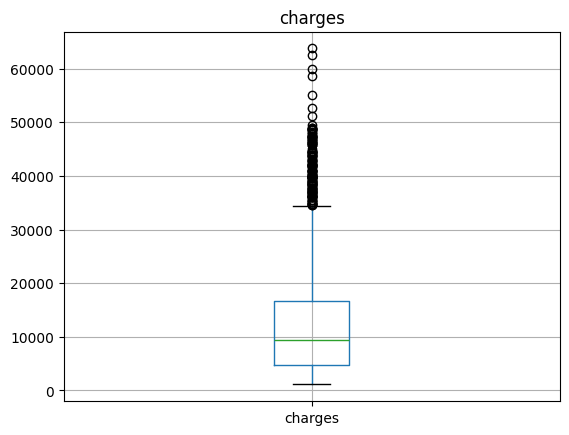

charges
Lower bound: -13109.15
Upper bound: 34489.35
Outliers: 139


In [69]:
# charges
plot_boxplot(df, "charges")
count_outliers_iqr(df, "charges")

### Charges Outlier Inspection

The boxplot of `charges` shows a large number of observations above the upper whisker, indicating many high-value outliers according to the IQR rule.

- The distribution of `charges` is strongly right-skewed (skewness = 1.52).
- Most individuals have relatively low medical costs, while a smaller number incur very high costs.
- The upper tail extends to approximately $63,770.
- These extreme values are likely valid observations rather than data quality errors, as high medical expenses are expected in healthcare and insurance datasets.
- Removing these observations would eliminate important high-cost cases that are relevant to the business problem.

**Decision:** Keep all observations. Do not remove outliers. A log transformation of `charges` may be considered during preprocessing to reduce skewness and improve model performance.

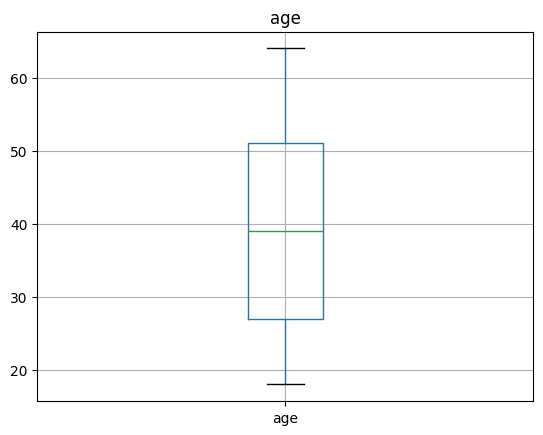

age
Lower bound: -9.00
Upper bound: 87.00
Outliers: 0


In [71]:
# age
plot_boxplot(df, "age")
# IQR thresholds
count_outliers_iqr(df, "age")

### Age Outlier Inspection

The `age` variable contains no outliers according to the IQR rule. All observations fall within the expected range of 18 to 64 years. The distribution is approximately symmetric (skewness = 0.06), and there is no evidence of data quality issues or unrealistic values.

**Decision:** Keep all observations. No transformation or outlier treatment is required.

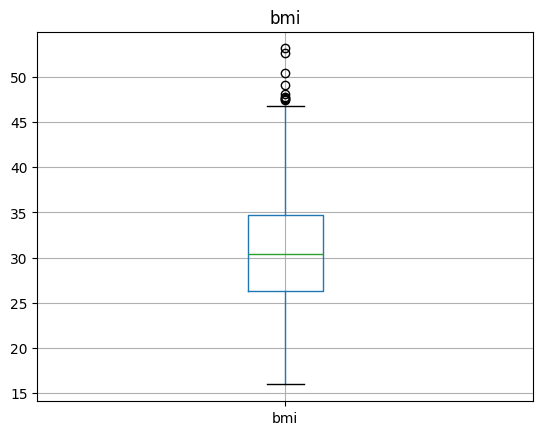

bmi
Lower bound: 13.70
Upper bound: 47.29
Outliers: 9


In [73]:
# bmi
plot_boxplot(df, "bmi")
# IQR thresholds
count_outliers_iqr(df, "bmi")

### BMI Outlier Inspection

The `bmi` variable contains 9 observations identified as outliers by the IQR rule (BMI > 47.29). These represent less than 1% of the dataset and are likely valid observations rather than data errors. The maximum BMI value is 53.13, which is extreme but medically possible. Since the distribution is only slightly right-skewed (skewness = 0.28), there is no strong justification for removing, capping, or transforming these values.

**Decision:** Keep all observations. No outlier treatment is required.

In [72]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


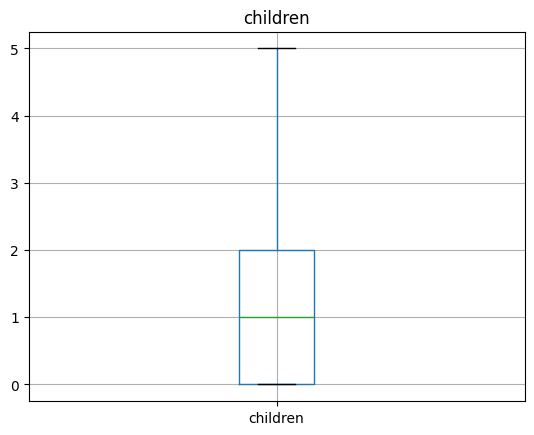

children
Lower bound: -3.00
Upper bound: 5.00
Outliers: 0


In [74]:
# children
plot_boxplot(df, "children")
# IQR thresholds
count_outliers_iqr(df, "children")

### Children Outlier Inspection

The `children` variable contains no outliers according to the IQR rule. All observations fall within the expected range of 0 to 5 dependent children. Since `children` is a discrete count variable rather than a continuous measurement, traditional outlier analysis is less informative. The observed values appear realistic and do not indicate any data quality issues.

**Decision:** Keep all observations. No outlier treatment is required.

| Feature  | Outliers                 | Decision                          |
| -------- | ------------------------ | --------------------------------- |
| charges  | Many high-value outliers | Keep, consider log transformation |
| bmi      | 9 high-value outliers    | Keep                              |
| age      | None                     | Keep                              |
| children | None                     | Keep                              |


## 7. Preprocessing Pipeline
Create a preprocessing pipeline for regression.

Suggested approach:
- One-hot encode categorical variables
- Standardize numerical variables
- Keep preprocessing fitted only on the training data

In [75]:
# Create a copy for modeling
df_model = df.copy()

In [76]:
# Remove duplicate observations
df_model = df_model.drop_duplicates()
print(f"Original rows: {len(df)}")
print(f"Model rows   : {len(df_model)}")

Original rows: 1338
Model rows   : 1337


In [96]:

categorical_features = [
    "sex",
    "smoker",
    "region"
]

numerical_features = [
    "age",
    "bmi",
    "children"
]

# preprocessor = ColumnTransformer(
#     transformers=[
#         (
#             "num",
#             StandardScaler(),
#             numerical_features
#         ),
#         (
#             "cat",
#             OneHotEncoder(handle_unknown="ignore"),
#             categorical_features
#         )
#     ]
# )

## 8. Prepare Train/Test Data Splits
Apply preprocessing through a pipeline to avoid data leakage.

In [ ]:
### functions

In [101]:
def train_and_evaluate_regression_model(
    df,
    numerical_features,
    categorical_features,
    target_column="charges",
    scale_numeric=True,
    test_size=0.2,
    random_state=42,
    use_log_target=False
):
    X = df.drop(target_column, axis=1)
    y = df[target_column]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state
    )

    numeric_transformer = (
        StandardScaler()
        if scale_numeric
        else "passthrough"
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numerical_features),
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
        ]
    )

    if use_log_target:
        regressor = TransformedTargetRegressor(
        regressor=LinearRegression(),
        func=np.log1p,
        inverse_func=np.expm1
    )
    else:
        regressor = LinearRegression()

    model = Pipeline([
        ("preprocessor", preprocessor),
        ("regressor", regressor)
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print(f"Mean Squared Error: {mse:.2f}")
    print(f"Root Mean Squared Error: {rmse:.2f}")
    print(f"R-squared: {r2:.2f}")

    return model, y_pred

In [116]:
def train_and_evaluate_decision_tree_model(
    df,
    numerical_features,
    categorical_features,
    target_column="charges",
    scale_numeric=True,
    test_size=0.2,
    random_state=42,
    use_log_target=False,
    max_depth=5
):
    X = df.drop(target_column, axis=1)
    y = df[target_column]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state
    )

    numeric_transformer = (
        StandardScaler()
        if scale_numeric
        else "passthrough"
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numerical_features),
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
        ]
    )

    base_regressor = DecisionTreeRegressor(
        max_depth=max_depth,
        random_state=random_state
    )

    if use_log_target:
        regressor = TransformedTargetRegressor(
            regressor=base_regressor,
            func=np.log1p,
            inverse_func=np.expm1
        )
    else:
        regressor = base_regressor

    model = Pipeline([
        ("preprocessor", preprocessor),
        ("regressor", regressor)
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print(f"Mean Squared Error: {mse:.2f}")
    print(f"Root Mean Squared Error: {rmse:.2f}")
    print(f"R-squared: {r2:.2f}")

    return model, y_pred

In [121]:
def train_and_evaluate_random_forest_model(
    df,
    numerical_features,
    categorical_features,
    target_column="charges",
    scale_numeric=True,
    test_size=0.2,
    random_state=42,
    use_log_target=False,
    n_estimators=100,
    max_depth=None
):
    X = df.drop(target_column, axis=1)
    y = df[target_column]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state
    )

    numeric_transformer = (
        StandardScaler()
        if scale_numeric
        else "passthrough"
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numerical_features),
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
        ]
    )

    base_regressor = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        random_state=random_state
    )

    if use_log_target:
        regressor = TransformedTargetRegressor(
            regressor=base_regressor,
            func=np.log1p,
            inverse_func=np.expm1
        )
    else:
        regressor = base_regressor

    model = Pipeline([
        ("preprocessor", preprocessor),
        ("regressor", regressor)
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print(f"Mean Squared Error: {mse:.2f}")
    print(f"Root Mean Squared Error: {rmse:.2f}")
    print(f"R-squared: {r2:.2f}")

    return model, y_pred

### Prediction

#### liner regression

##### main variant

In [102]:
model, y_pred = train_and_evaluate_regression_model(
    df_model,
    numerical_features,
    categorical_features
)

Mean Squared Error: 35478020.68
Root Mean Squared Error: 5956.34
R-squared: 0.81


The model achieved an R² score of 0.81, indicating that approximately 81% of the variation in medical charges can be explained by the available features. The RMSE is approximately $5,956, meaning that predictions differ from actual charges by about $6,000 on average. Considering the wide range of medical costs in the dataset ($1,122 to $63,770), this represents a reasonably good predictive performance for a simple linear regression model.

##### charge log transform variant

In [108]:
model, y_pred = train_and_evaluate_regression_model(
    df_model,
    numerical_features,
    categorical_features,
    use_log_target=True
)

Mean Squared Error: 51797278.35
Root Mean Squared Error: 7197.03
R-squared: 0.72


A log transformation of the target variable was tested because `charges` is strongly right-skewed. However, the model with log-transformed target performed worse on the original charge scale, with RMSE increasing from 5,956 to 7,197 and R² decreasing from 0.81 to 0.72. Therefore, the original target scale was kept for the baseline regression model.

##### without children feature variant

In [109]:
numerical_features_no_children = [
    "age",
    "bmi"
]

model_no_children, y_pred_no_children = (
    train_and_evaluate_regression_model(
        df_model,
        numerical_features_no_children,
        categorical_features
    )
)

Mean Squared Error: 35428059.80
Root Mean Squared Error: 5952.15
R-squared: 0.81


The `children` feature was removed as an experiment because exploratory analysis showed a very weak correlation with the target variable (0.07). After retraining the model without this feature, the performance remained virtually unchanged (RMSE: 5952 vs 5956, R²: 0.81 in both cases). This suggests that the number of children contributes little predictive information for estimating medical insurance costs in this dataset.

##### Without scaling

In [111]:
train_and_evaluate_regression_model(
    df_model,
    numerical_features,
    categorical_features,
    scale_numeric=False
)

Mean Squared Error: 35478020.68
Root Mean Squared Error: 5956.34
R-squared: 0.81


(Pipeline(steps=[('preprocessor',
                  ColumnTransformer(transformers=[('num', 'passthrough',
                                                   ['age', 'bmi', 'children']),
                                                  ('cat',
                                                   OneHotEncoder(handle_unknown='ignore'),
                                                   ['sex', 'smoker',
                                                    'region'])])),
                 ('regressor', LinearRegression())]),
 array([ 8.14369388e+03,  5.73711568e+03,  1.43693149e+04,  3.17455136e+04,
         8.96238666e+03,  1.31497224e+04,  3.04467607e+04,  1.45328881e+03,
         1.06330184e+04,  1.13189438e+04,  1.03778536e+04,  3.31184377e+04,
         3.10772527e+04,  1.74119253e+04,  1.08016743e+04,  9.52889964e+03,
         4.16103784e+03,  3.17315373e+04,  3.21938875e+03,  5.22992460e+03,
         3.54979004e+03,  3.02837740e+04,  1.48989509e+04,  3.04569093e+04,
         3.1107766


Effect of Feature Scaling

An additional experiment was performed without standardizing the numerical features. The model achieved exactly the same performance as the baseline model (RMSE = 5956, R² = 0.81).

This result is expected for Linear Regression because the algorithm is generally insensitive to the scale of the input variables. Scaling changes the magnitude of the model coefficients but does not significantly affect the predictions.

**Conclusion:** Feature scaling did not improve model performance in this case. However, scaling was retained in the preprocessing pipeline because it is considered good practice and improves compatibility with many other machine learning algorithms.

##### Only age, bmi, smoker

In [113]:
numerical_features_core = [
    "age",
    "bmi"
]

categorical_features_core = [
    "smoker"
]

train_and_evaluate_regression_model(
    df_model,
    numerical_features_core,
    categorical_features_core
)

Mean Squared Error: 35841574.82
Root Mean Squared Error: 5986.78
R-squared: 0.80


(Pipeline(steps=[('preprocessor',
                  ColumnTransformer(transformers=[('num', StandardScaler(),
                                                   ['age', 'bmi']),
                                                  ('cat',
                                                   OneHotEncoder(handle_unknown='ignore'),
                                                   ['smoker'])])),
                 ('regressor', LinearRegression())]),
 array([ 8433.67443577,  4336.46678013, 13165.0382606 , 30593.69534864,
         8738.64384303, 13004.1887831 , 29273.63576136,  2177.09021482,
        10922.95093736, 10315.83022735, 11021.84491859, 33740.33309282,
        30613.92158231, 18004.87150727,  9656.23179762,  9311.37354392,
         4325.12010919, 32099.96630635,  3001.71338943,  5552.62898392,
         4325.12010919, 29913.00795743, 14580.01800456, 30752.45719245,
        31444.92261851,  4769.02189756, 35187.05259131, 37413.46842278,
        10952.8675722 , 12177.75978526,  6505.96

A reduced model using only the features `age`, `bmi`, and `smoker` was tested because exploratory analysis identified them as the strongest predictors of medical costs.

The reduced model achieved an R² score of 0.80 compared to 0.81 for the full model, while RMSE increased only slightly from 5,956 to 5,987.

This suggests that most of the predictive information in the dataset is contained in these three features. The remaining variables (`sex`, `region`, and `children`) provide only a small additional contribution to model performance.

| Model                   | RMSE |   R² |
| ----------------------- | ---: | ---: |
| Baseline (all features) | 5956 | 0.81 |
| Without children        | 5952 | 0.81 |
| Without scaling         | 5956 | 0.81 |
| Age + BMI + Smoker only | 5987 | 0.80 |
| Log(charges)            | 7197 | 0.72 |


#### decision_tree

##### main variant max depth = 5

In [117]:
tree_model, tree_y_pred = train_and_evaluate_decision_tree_model(
    df_model,
    numerical_features,
    categorical_features
)

Mean Squared Error: 19507828.70
Root Mean Squared Error: 4416.77
R-squared: 0.89


##### main variant max depth = 3

In [118]:
tree_model, tree_y_pred = train_and_evaluate_decision_tree_model(
    df_model,
    numerical_features,
    categorical_features,
    max_depth=3
)

Mean Squared Error: 19670972.64
Root Mean Squared Error: 4435.20
R-squared: 0.89


##### main variant max depth = 10

In [119]:
tree_model, tree_y_pred = train_and_evaluate_decision_tree_model(
    df_model,
    numerical_features,
    categorical_features,
    max_depth=3
)

Mean Squared Error: 19670972.64
Root Mean Squared Error: 4435.20
R-squared: 0.89


| Model                   | RMSE |   R² |
| ----------------------- | ---: | ---: |
| Linear Regression       | 5956 | 0.81 |
| Decision Tree (depth=3) | 4435 | 0.89 |
| Decision Tree (depth=5) | 4417 | 0.89 |


##### Charge log transform variant

In [134]:
tree_model, tree_y_pred = train_and_evaluate_decision_tree_model(
    df_model,
    numerical_features,
    categorical_features,
    use_log_target=True
)

Mean Squared Error: 18033447.20
Root Mean Squared Error: 4246.58
R-squared: 0.90


#### random_forest

##### main variant max depth = 5

In [122]:
forest_model, forest_y_pred = train_and_evaluate_random_forest_model(
    df_model,
    numerical_features,
    categorical_features
)

Mean Squared Error: 21834508.01
Root Mean Squared Error: 4672.74
R-squared: 0.88


##### main variant max depth = 3

In [125]:
forest_model, forest_y_pred = train_and_evaluate_random_forest_model(
    df_model,
    numerical_features,
    categorical_features,
    max_depth=3
)

Mean Squared Error: 18641371.47
Root Mean Squared Error: 4317.57
R-squared: 0.90


##### main variant max depth = 10

In [126]:
forest_model, forest_y_pred = train_and_evaluate_random_forest_model(
    df_model,
    numerical_features,
    categorical_features,
    max_depth=10
)

Mean Squared Error: 21129263.21
Root Mean Squared Error: 4596.66
R-squared: 0.89


##### Charge log transform variant

In [135]:
forest_model, forest_y_pred = train_and_evaluate_random_forest_model(
    df_model,
    numerical_features,
    categorical_features,
    use_log_target=True
)

Mean Squared Error: 19130685.10
Root Mean Squared Error: 4373.86
R-squared: 0.90


##### Charge log transform variant, max depth = 3

In [136]:
forest_model, forest_y_pred = train_and_evaluate_random_forest_model(
    df_model,
    numerical_features,
    categorical_features,
    use_log_target=True,
    max_depth=4
)

Mean Squared Error: 18092875.15
Root Mean Squared Error: 4253.57
R-squared: 0.90


#### Compare variants

| Model         | Log Target | Max Depth |     RMSE |       R² |
| ------------- | ---------- | --------: | -------: | -------: |
| Random Forest | No         |      None |     4673 |     0.88 |
| Random Forest | Yes        |      None |     4374 |     0.90 |
| Random Forest | Yes        |         3 |     4318 |     0.90 |
| Random Forest | Yes        |         4 | **4254** | **0.90** |
| Decision Tree | Yes        |         5 | **4247** | **0.90** |


#### Feature importnace

In [141]:
feature_names = forest_model.named_steps["preprocessor"].get_feature_names_out()
# print(feature_names)

importances = forest_model.named_steps["regressor"].regressor_.feature_importances_
# print(importances)

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(
    by="importance",
    ascending=False
)

print(importance_df)

                  feature  importance
0                num__age    0.407361
6         cat__smoker_yes    0.263532
5          cat__smoker_no    0.254539
2           num__children    0.037667
1                num__bmi    0.035710
7   cat__region_northeast    0.000532
10  cat__region_southwest    0.000290
8   cat__region_northwest    0.000166
9   cat__region_southeast    0.000134
4           cat__sex_male    0.000064
3         cat__sex_female    0.000005


| Original feature | Combined importance |
| ---------------- | ------------------: |
| smoker           |              ~0.518 |
| age              |              ~0.407 |
| children         |              ~0.038 |
| bmi              |              ~0.036 |
| region           |              ~0.001 |
| sex              |              ~0.000 |


## 9. Bonus: Compare Before vs After Preprocessing

Goal: show why preprocessing matters.

Suggested comparison:
1. Try to train a model on the raw dataset.
2. Observe what fails or performs poorly.
3. Train the same model after preprocessing.
4. Compare metrics and explain the difference.

Questions to answer:
- Can the model train on raw categorical columns?
- What preprocessing steps were required?
- Did performance improve after preprocessing?
- Which preprocessing step likely mattered most?

### Before vs After Preprocessing

A Linear Regression model could not be trained directly on the raw dataset because the categorical features (`sex`, `smoker`, and `region`) contain string values. These variables had to be converted into numerical form using one-hot encoding.

After preprocessing, the model achieved:

- RMSE ≈ 5,956
- R² ≈ 0.81

An additional experiment showed that standardizing the numerical variables had no measurable impact on model performance. This is expected because Linear Regression is generally insensitive to feature scale.

The most important preprocessing step was one-hot encoding, which enabled the model to use categorical information. Scaling was retained as good practice but was not required for model performance.

## 9. Bonus: Compare Before vs After Preprocessing

Goal: show why preprocessing matters.

Suggested comparison:
1. Try to train a model on the raw dataset.
2. Observe what fails or performs poorly.
3. Train the same model after preprocessing.
4. Compare metrics and explain the difference.

Questions to answer:
- Can the model train on raw categorical columns?
- What preprocessing steps were required?
- Did performance improve after preprocessing?
- Which preprocessing step likely mattered most?

## 10. Reflection
Write a short summary:
- What data quality issues did you find?
- Which preprocessing steps did you apply?
- What changed after preprocessing?
- What would you improve next?

# Summary

## Dataset

**Medical Insurance Charges**

**Target Variable:** `charges`

**Goal:** Predict medical insurance costs using demographic and health-related features.

---

# Exploratory Data Analysis (EDA)

## Target Variable: `charges`

### Distribution

* Strong right skew
* Skewness = **1.52**
* Many observations with moderate costs
* Small number of very expensive cases

### Outlier Analysis

| Feature  | Outliers |
| -------- | -------: |
| charges  |      139 |
| bmi      |        9 |
| age      |        0 |
| children |        0 |

### Decision

* Outliers appear to be valid observations rather than data errors.
* All observations were retained.
* A log transformation of the target variable was tested during modeling.

---

# Feature Analysis

## Categorical Features

### smoker

| smoker | average charges |
| ------ | --------------: |
| no     |           8,434 |
| yes    |          32,050 |

**Observation:** Very strong relationship with the target variable.

### sex

| sex    | average charges |
| ------ | --------------: |
| male   |          13,957 |
| female |          12,570 |

**Observation:** Weak relationship with the target variable.

### region

| region    | average charges |
| --------- | --------------: |
| southeast |          14,735 |
| northeast |          13,406 |
| northwest |          12,418 |
| southwest |          12,347 |

**Observation:** Moderate differences between regions.

---

## Numerical Features

### age

* Correlation with charges: **0.30**
* Average charges increase steadily with age.

### bmi

* Correlation with charges: **0.20**
* Higher BMI is generally associated with higher charges.

### children

* Correlation with charges: **0.07**
* Weak relationship with the target variable.

---

# Data Cleaning and Preprocessing

### Data Cleaning

* Removed 1 duplicate row.

### Feature Encoding

Applied One-Hot Encoding to:

* `sex`
* `smoker`
* `region`

### Feature Scaling

Applied StandardScaler to:

* `age`
* `bmi`
* `children`

### Train/Test Split

```python
test_size = 0.2
random_state = 42
```

---

# Linear Regression Experiments

## Baseline Model

| Metric | Value |
| ------ | ----: |
| RMSE   | 5,956 |
| R²     |  0.81 |

### Without Scaling

| Metric | Value |
| ------ | ----: |
| RMSE   | 5,956 |
| R²     |  0.81 |

**Conclusion:** Scaling had no measurable impact.

### Without `children`

| Metric | Value |
| ------ | ----: |
| RMSE   | 5,952 |
| R²     |  0.81 |

**Conclusion:** Removing `children` had almost no effect.

### Core Features Only (`age`, `bmi`, `smoker`)

| Metric | Value |
| ------ | ----: |
| RMSE   | 5,987 |
| R²     |  0.80 |

**Conclusion:** Most predictive power comes from these three features.

### Log-Transformed Target

| Metric | Value |
| ------ | ----: |
| RMSE   | 7,197 |
| R²     |  0.72 |

**Conclusion:** Log transformation significantly worsened Linear Regression performance.

---

# Decision Tree Regressor

## Baseline

| Metric | Value |
| ------ | ----: |
| RMSE   | 4,417 |
| R²     |  0.89 |

**Conclusion:** Significant improvement over Linear Regression.

## Log-Transformed Target

| Metric | Value |
| ------ | ----: |
| RMSE   | 4,247 |
| R²     |  0.90 |

**Conclusion:** Best-performing model in the project.

---

# Random Forest Regressor

## Baseline

| Metric | Value |
| ------ | ----: |
| RMSE   | 4,673 |
| R²     |  0.88 |

## Log-Transformed Target

| Metric | Value |
| ------ | ----: |
| RMSE   | 4,374 |
| R²     |  0.90 |

## Log-Transformed Target + max_depth=4

| Metric | Value |
| ------ | ----: |
| RMSE   | 4,254 |
| R²     |  0.90 |

**Conclusion:** Very close to the best Decision Tree model.

---

# Feature Importance Analysis (Random Forest)

| Feature           | Importance |
| ----------------- | ---------: |
| smoker (combined) |     ~0.518 |
| age               |     ~0.407 |
| children          |     ~0.038 |
| bmi               |     ~0.036 |
| region            |     ~0.001 |
| sex               |     ~0.000 |

### Conclusion

The strongest predictors of medical charges are:

1. `smoker`
2. `age`
3. `bmi`
4. `children`
5. `region`
6. `sex`

This largely confirms the findings from the exploratory analysis.

---

# Final Model Ranking

| Rank | Model                                    |  RMSE |   R² |
| ---- | ---------------------------------------- | ----: | ---: |
| 🥇   | Decision Tree + Log Target               | 4,247 | 0.90 |
| 🥈   | Random Forest + Log Target + max_depth=4 | 4,254 | 0.90 |
| 🥉   | Random Forest + Log Target               | 4,374 | 0.90 |
| 4    | Decision Tree                            | 4,417 | 0.89 |
| 5    | Random Forest                            | 4,673 | 0.88 |
| 6    | Linear Regression                        | 5,956 | 0.81 |
| 7    | Linear Regression + Log Target           | 7,197 | 0.72 |

---

# Key Findings

* `smoker` is the strongest predictor of insurance charges.
* `age` is the strongest numerical predictor.
* `sex` and `region` contribute very little predictive information.
* Scaling did not improve Linear Regression performance.
* Removing `children` had almost no effect.
* Log transformation worsened Linear Regression but improved tree-based models.
* Tree-based models capture nonlinear relationships much better than Linear Regression.
* Decision Tree and Random Forest achieved substantially better predictive performance than Linear Regression.

---

# Possible Future Exploration

### Gradient Boosting Regressor

Gradient Boosting Regressor could be evaluated as an additional tree-based ensemble model and may further improve predictive performance.

### Cross Validation

K-Fold Cross Validation could be used to obtain a more robust estimate of model performance and reduce dependence on a single train/test split.
